In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = '/content/drive/My Drive/TÜ Andmeteadus MSc/Machine Learning I/Project/cgm.txt'
df = pd.read_csv(file_path, sep="|")
df.head()

,PtID,Period,DataDtTm,CGM
0,1,1. Baseline,11DEC17:23:59:25,172
1,1,1. Baseline,12DEC17:00:04:24,170
2,1,1. Baseline,12DEC17:00:09:24,167
3,1,1. Baseline,12DEC17:00:14:25,163
4,1,1. Baseline,12DEC17:00:19:25,160


In [ ]:
#kuupäeva formaadi veerg
df['DataDtTm'] = pd.to_datetime(df['DataDtTm'], format='%d%b%y:%H:%M:%S')

#Sorteeri kindluse mõttes
df = df.sort_values(['PtID', 'DataDtTm'])

# Arvuta ajavahe järjestikuste mõõtmiste vahel
df['delta_min'] = df.groupby('PtID')['DataDtTm'].diff().dt.total_seconds() / 60

#  Kontrolli tüüpilist sammu
df['delta_min'].describe()


,delta_min
count,9.032067e+06
mean,5.393085e+00
std,3.098620e+02
min,4.500000e+00
25%,5.000000e+00
50%,5.000000e+00
75%,5.000000e+00
max,9.275909e+05


In [ ]:
# Puuduvad väärtused
df['CGM'].isna().sum()

# Väärtuste vahemik
df['CGM'].describe()

# Eemalda või interpoleeri lüngad
df['CGM_interp'] = df.groupby('PtID')['CGM'].transform(lambda x: x.interpolate(limit=3))

print(df['CGM'].isna().sum())
print(df['CGM'].describe())

# Teisendus mg/dL → mmol/L
df['CGM_mmol'] = df['CGM'] / 18

# Märgi, kas väärtus on vahemikus 4–10 mmol/L
df['in_range'] = df['CGM_mmol'].between(4, 10)


0
count    9.032235e+06
mean     1.604207e+02
std      6.120771e+01
min      3.900000e+01
25%      1.160000e+02
50%      1.480000e+02
75%      1.930000e+02
max      4.010000e+02
Name: CGM, dtype: float64


Patsient 9

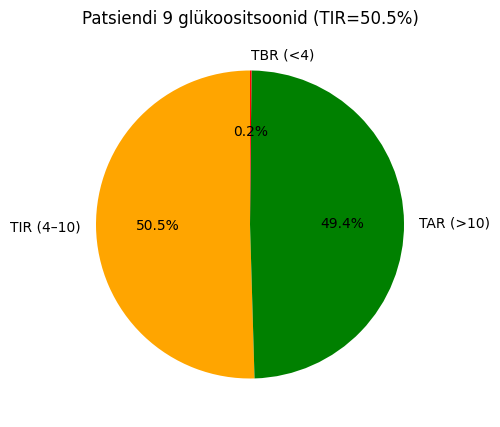

In [ ]:
import numpy as np
pt = 9
start_date = "2017-12-28"
end_date   = "2018-01-12"

subset = df[df['PtID'] == pt].copy()

subset['DataDtTm'] = pd.to_datetime(subset['DataDtTm'])
subset = subset[(subset['DataDtTm'] >= start_date) & (subset['DataDtTm'] <= end_date)]

subset['CGM_mmol'] = subset['CGM'] / 18

subset['zone'] = np.select(
    [subset['CGM_mmol'] < 4,
     subset['CGM_mmol'].between(4, 10),
     subset['CGM_mmol'] > 10],
    ['TBR (<4)', 'TIR (4–10)', 'TAR (>10)'],
    default='missing'
).astype(object)

counts = subset['zone'].value_counts(normalize=True) * 100

plt.figure(figsize=(5,5))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%',
        colors=['orange','green','red','gray'], startangle=90)
plt.title(f'Patsiendi {pt} glükoositsoonid (TIR={counts.get("TIR (4–10)", 0):.1f}%)')
plt.show()


In [ ]:
df['date'] = df['DataDtTm'].dt.date
daily = df.groupby(['PtID', 'date'])['CGM'].agg(['mean', 'std', 'min', 'max'])


In [ ]:
subset = subset.sort_values('DataDtTm')
subset['diff'] = subset['CGM_mmol'].diff()
subset['dt_minutes'] = subset['DataDtTm'].diff().dt.total_seconds() / 60
subset['slope_mmol_per_min'] = subset['diff'] / subset['dt_minutes']
subset.head(25)

,PtID,Period,DataDtTm,CGM,delta_min,CGM_interp,CGM_mmol,in_range,zone,diff,dt_minutes,slope_mmol_per_min
8442164,9,1. Baseline,2018-01-04 23:57:01,246,NaN,246,13.666667,False,TAR (>10),NaN,NaN,NaN
8442165,9,1. Baseline,2018-01-05 00:02:01,245,5.000000,245,13.611111,False,TAR (>10),-0.055556,5.000000,-0.011111
8442166,9,1. Baseline,2018-01-05 00:07:02,242,5.016667,242,13.444444,False,TAR (>10),-0.166667,5.016667,-0.033223
8442167,9,1. Baseline,2018-01-05 00:12:00,239,4.966667,239,13.277778,False,TAR (>10),-0.166667,4.966667,-0.033557
8442168,9,1. Baseline,2018-01-05 00:17:01,239,5.016667,239,13.277778,False,TAR (>10),0.000000,5.016667,0.000000
8442169,9,1. Baseline,2018-01-05 00:22:01,240,5.000000,240,13.333333,False,TAR (>10),0.055556,5.000000,0.011111
8442170,9,1. Baseline,2018-01-05 00:27:01,239,5.000000,239,13.277778,False,TAR (>10),-0.055556,5.000000,-0.011111
8442171,9,1. Baseline,2018-01-05 00:32:01,235,5.000000,235,13.055556,False,TAR (>10),-0.222222,5.000000,-0.044444
8442172,9,1. Baseline,2018-01-05 00:37:00,230,4.983333,230,12.777778,False,TAR (>10),-0.277778,4.983333,-0.055741
8442173,9,1. Baseline,2018-01-05 00:42:02,226,5.033333,226,12.555556,False,TAR (>10),-0.222222,5.033333,-0.044150


In [ ]:
subset['is_rising'] = subset['slope_mmol_per_min'] > 0

# Grupeerime järjestikused tõusud
subset['rise_group'] = (subset['is_rising'] != subset['is_rising'].shift()).cumsum()


#arvutame tõusud
rise_segments = (
    subset[subset['is_rising']]
    .groupby('rise_group')
    .agg(
        start_time=('DataDtTm', 'first'),
        end_time=('DataDtTm', 'last'),
        start_value=('CGM_mmol', 'first'),
        end_value=('CGM_mmol', 'last'),
        amplitude=('CGM_mmol', lambda x: x.max() - x.min()),
        duration_min=('dt_minutes', 'sum'),
        mean_slope=('slope_mmol_per_min', 'mean'),
        max_slope=('slope_mmol_per_min', 'max')
    )
).reset_index(drop=True)


In [ ]:
subset.head(102)

,PtID,Period,DataDtTm,CGM,delta_min,CGM_interp,CGM_mmol,in_range,zone,diff,dt_minutes,slope_mmol_per_min,is_rising,rise_group
8442164,9,1. Baseline,2018-01-04 23:57:01,246,NaN,246,13.666667,False,TAR (>10),NaN,NaN,NaN,False,1
8442165,9,1. Baseline,2018-01-05 00:02:01,245,5.000000,245,13.611111,False,TAR (>10),-0.055556,5.000000,-0.011111,False,1
8442166,9,1. Baseline,2018-01-05 00:07:02,242,5.016667,242,13.444444,False,TAR (>10),-0.166667,5.016667,-0.033223,False,1
8442167,9,1. Baseline,2018-01-05 00:12:00,239,4.966667,239,13.277778,False,TAR (>10),-0.166667,4.966667,-0.033557,False,1
8442168,9,1. Baseline,2018-01-05 00:17:01,239,5.016667,239,13.277778,False,TAR (>10),0.000000,5.016667,0.000000,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8442261,9,1. Baseline,2018-01-05 08:01:58,137,5.000000,137,7.611111,True,TIR (4–10),0.000000,5.000000,0.000000,False,17
8442262,9,1. Baseline,2018-01-05 08:06:58,138,5.000000,138,7.666667,True,TIR (4–10),0.055556,5.000000,0.011111,True,18
8442263,9,1. Baseline,2018-01-05 08:11:59,140,5.016667,140,7.777778,True,TIR (4–10),0.111111,5.016667,0.022148,True,18
8442264,9,1. Baseline,2018-01-05 08:16:59,141,5.000000,141,7.833333,True,TIR (4–10),0.055556,5.000000,0.011111,True,18


In [ ]:
subset[['DataDtTm','CGM_mmol','slope_mmol_per_min','is_rising','rise_group']].head(20)


,DataDtTm,CGM_mmol,slope_mmol_per_min,is_rising,rise_group
8442164,2018-01-04 23:57:01,13.666667,NaN,False,1
8442165,2018-01-05 00:02:01,13.611111,-0.011111,False,1
8442166,2018-01-05 00:07:02,13.444444,-0.033223,False,1
8442167,2018-01-05 00:12:00,13.277778,-0.033557,False,1
8442168,2018-01-05 00:17:01,13.277778,0.000000,False,1
8442169,2018-01-05 00:22:01,13.333333,0.011111,True,2
8442170,2018-01-05 00:27:01,13.277778,-0.011111,False,3
8442171,2018-01-05 00:32:01,13.055556,-0.044444,False,3
8442172,2018-01-05 00:37:00,12.777778,-0.055741,False,3
8442173,2018-01-05 00:42:02,12.555556,-0.044150,False,3


In [ ]:
subset["is_rising"] = subset["slope_mmol_per_min"] > 0
subset["rise_group"] = (subset["is_rising"] != subset["is_rising"].shift()).cumsum()
long_rises = rise_segments[rise_segments["duration_min"] >= 120]
long_rises["start_hour"] = long_rises["start_time"].dt.hour
print(long_rises["start_hour"].value_counts().sort_index())

start_hour
14    1
17    1
Name: count, dtype: int64


/tmp/ipython-input-938733473.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  long_rises["start_hour"] = long_rises["start_time"].dt.hour


In [ ]:
counts = long_rises["start_hour"].value_counts()

mean_count = counts.mean()           # tõusude keskmine arv tunnis
problem_hours = counts[counts > mean_count].index.tolist()

print("Tõusude arv tunniti:")
print(counts.sort_index())

print(f"\nKeskmine tõusude arv tunniti: {mean_count:.2f}")
print("Probleemsed tunnid (rohkem tõuse kui keskmiselt):", problem_hours)


Tõusude arv tunniti:
start_hour
14    1
17    1
Name: count, dtype: int64

Keskmine tõusude arv tunniti: 1.00
Probleemsed tunnid (rohkem tõuse kui keskmiselt): []


In [ ]:
long_rises["recovery_time_minutes"] = np.nan

for idx, row in long_rises.iterrows():
    peak_time = row["end_time"]
    two_hours_after = peak_time + pd.Timedelta(hours=2)

    # võta selle perioodi kõik mõõtmised
    window = subset[
        (subset["DataDtTm"] > peak_time) &
        (subset["DataDtTm"] <= two_hours_after)
    ]

    # baseline (võid asendada oma baselinem mõistega)
    baseline = subset["CGM_mmol"].median()

    # esimene koht kus langeb baseline+1 lähedale
    hit = window[window["CGM_mmol"] <= baseline + 1]

    if not hit.empty:
        t = (hit.iloc[0]["DataDtTm"] - peak_time).total_seconds()/60
        long_rises.at[idx, "recovery_time_minutes"] = t


/tmp/ipython-input-1436154203.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  long_rises["recovery_time_minutes"] = np.nan


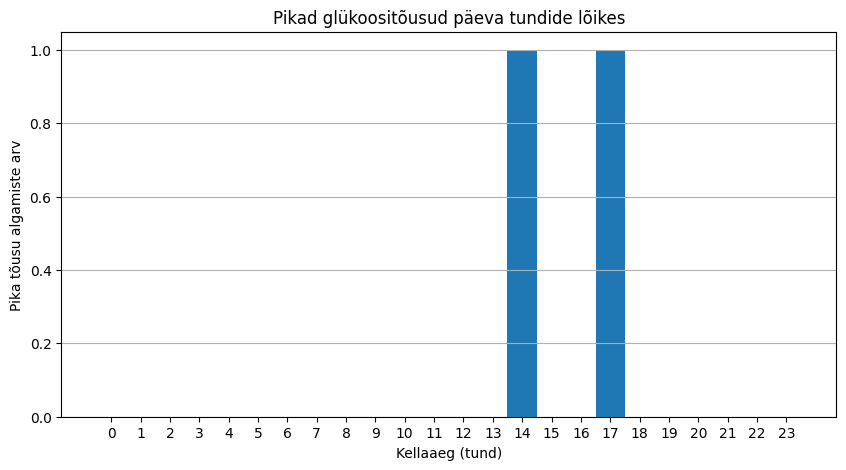

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(long_rises["start_hour"], bins=range(25), align='left')

plt.xticks(range(24))
plt.xlabel("Kellaaeg (tund)")
plt.ylabel("Pika tõusu algamiste arv")
plt.title("Pikad glükoositõusud päeva tundide lõikes")
plt.grid(axis='y')
plt.show()

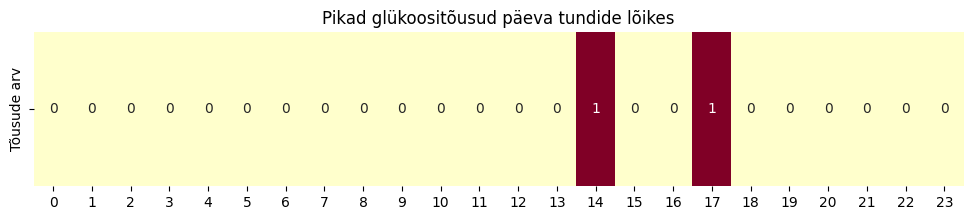

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np

counts = long_rises["start_hour"].value_counts().sort_index()
data = np.zeros((1, 24))
for hour, count in counts.items():
    data[0, hour] = count

plt.figure(figsize=(12,2))
sns.heatmap(data, cmap="YlOrRd", annot=True, cbar=False,
            xticklabels=range(24), yticklabels=["Tõusude arv"])
plt.title("Pikad glükoositõusud päeva tundide lõikes")
plt.show()


In [ ]:
counts = long_rises["start_hour"].value_counts()
max_count = counts.max()

# kõik tunnid, mis esinevad max_count arv kordi
problem_hours = counts[counts == max_count].index.tolist()

print("Probleemsed tunnid:", problem_hours)


Probleemsed tunnid: [14, 17]


In [ ]:
for hour in problem_hours:

    # filtreeri ainult selle tunni tõusud
    subset_rises = long_rises[ long_rises["start_hour"] == hour ].copy()

    if subset_rises.empty:
        continue

    # arvutused
    avg_peak = subset_rises["end_value"].mean()
    max_peak = subset_rises["end_value"].max()

    avg_slope = subset_rises["mean_slope"].mean()
    max_slope = subset_rises["max_slope"].max()

    avg_recovery = subset_rises["recovery_time_minutes"].mean()
    max_recovery = subset_rises["recovery_time_minutes"].max()

    print(f"\n======================")
    print(f"Tund: {hour}")
    print(f"Tõusude arv: {len(subset_rises)}")
    print(f"======================")
    print(f"Keskmine tipp CGM_mmol: {avg_peak:.2f}")
    print(f"Maksimaalne tipp CGM_mmol: {max_peak:.2f}")
    print(f"Keskmine slope (mmol/L/min): {avg_slope:.4f}")
    print(f"Maksimaalne slope (mmol/L/min): {max_slope:.4f}")
    print(f"Keskmine taastumisaeg (min): {avg_recovery:.1f}")
    print(f"Pikim taastumisaeg (min): {max_recovery:.1f}")

#Võrdluseks:
#normaalne tõus pärast väga väikest toitu: ~1 mmol/L tunnis
#märkimisväärne tõus: 2–3 mmol/L tunnis
#tugev söögijärgne tõus: 4+ mmol/L tunnis
#GLP-1 või insuliiniprobleemidega: 5–10+ mmol/L tunnis


Tund: 14
Tõusude arv: 1
Keskmine tipp CGM_mmol: 15.33
Maksimaalne tipp CGM_mmol: 15.33
Keskmine slope (mmol/L/min): 0.0636
Maksimaalne slope (mmol/L/min): 0.1115
Keskmine taastumisaeg (min): 90.0
Pikim taastumisaeg (min): 90.0

Tund: 17
Tõusude arv: 1
Keskmine tipp CGM_mmol: 21.17
Maksimaalne tipp CGM_mmol: 21.17
Keskmine slope (mmol/L/min): 0.0772
Maksimaalne slope (mmol/L/min): 0.1230
Keskmine taastumisaeg (min): nan
Pikim taastumisaeg (min): nan


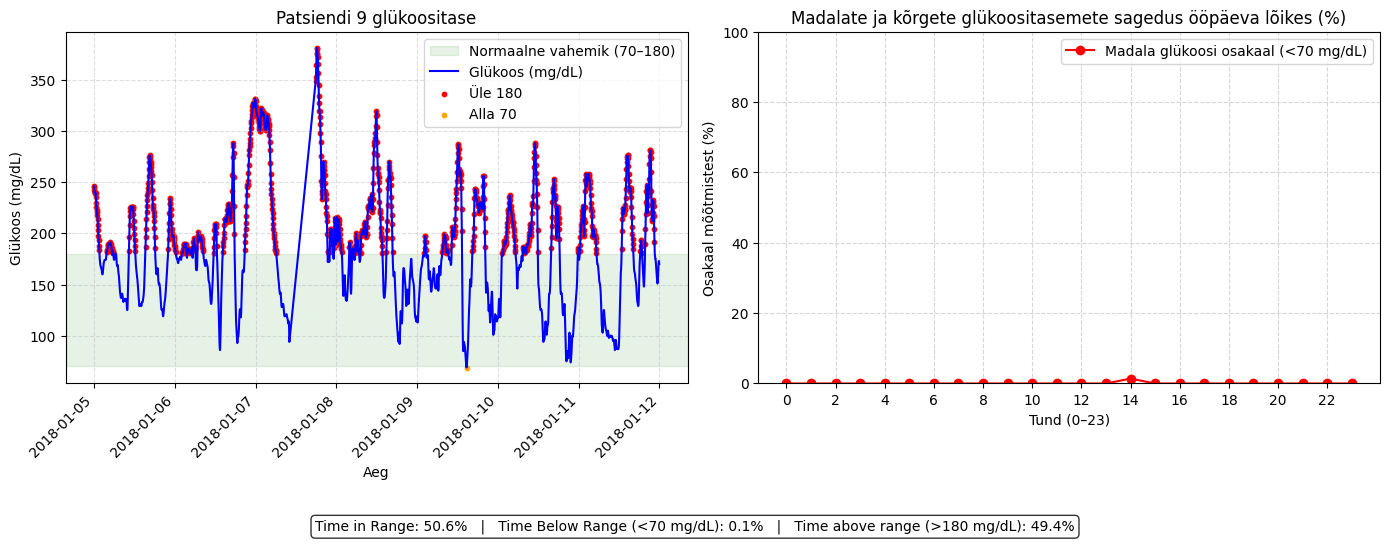

In [ ]:
# teisendame aja datetime'iks
df['DataDtTm'] = pd.to_datetime(df['DataDtTm'], format='%d%b%y:%H:%M:%S')

for pt in range(9,10):
    # vali patsiendi ja kuupäeva vahemiku andmed
    subset = df[
        (df['PtID'] == pt) &
        (df['DataDtTm'].between(start_date, end_date))
    ].copy()

    if subset.empty:
        print(f"Patsiendil {pt} pole andmeid vahemikus {start_date}–{end_date}.")
        continue

    # arvutused
    subset['CGM_mmol'] = subset['CGM'] / 18
    subset['hour'] = subset['DataDtTm'].dt.hour
    subset['is_low'] = subset['CGM'] < 70

    # mitu korda tunnis on väärtus madal
    hourly_low = subset.groupby('hour')['is_low'].mean() * 100

    # --- joonis kahe alamgraafikuga ---
    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    # Vasak: glükoositrend ajas
    ax1 = axes[0]
    ax1.axhspan(70, 180, color='green', alpha=0.1, label='Normaalne vahemik (70–180)')
    ax1.plot(subset['DataDtTm'], subset['CGM'], color='blue', label='Glükoos (mg/dL)')
    ax1.scatter(subset['DataDtTm'][subset['CGM'] > 180], subset['CGM'][subset['CGM'] > 180],
                color='red', s=10, label='Üle 180')
    ax1.scatter(subset['DataDtTm'][subset['CGM'] < 70], subset['CGM'][subset['CGM'] < 70],
                color='orange', s=10, label='Alla 70')
    ax1.set_title(f'Patsiendi {pt} glükoositase')
    ax1.set_xlabel('Aeg')
    ax1.set_ylabel('Glükoos (mg/dL)')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.4)
    plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')


    TIR = (subset['CGM'].between(70,180)).mean() * 100
    TBR = (subset['CGM'] < 70).mean() * 100
    TAR = (subset['CGM'] > 180).mean() * 100
    # Lisa tekst kogu joonise alla (fig tasemel)
    fig.text(0.5, -0.05,
            f"Time in Range: {TIR:.1f}%   |   Time Below Range (<70 mg/dL): {TBR:.1f}%   |   Time above range (>180 mg/dL): {TAR:.1f}%",
            ha='center', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


    ax2 = axes[1]

    # arvutame ka kõrgete väärtuste (TAR) protsendi tunnis
    hourly_high = subset.groupby('hour')['CGM'].apply(lambda x: (x > 180).mean() * 100)

    # joonista mõlemad
    ax2.plot(hourly_low.index, hourly_low.values, marker='o', color='red', label='Madala glükoosi osakaal (<70 mg/dL)')

    ax2.set_ylim(0, 100)

    # lisa abijoon
    ax2.axhline(0, color='gray', linewidth=0.5)

    # sätted
    ax2.set_title('Madalate ja kõrgete glükoositasemete sagedus ööpäeva lõikes (%)')
    ax2.set_xlabel('Tund (0–23)')
    ax2.set_ylabel('Osakaal mõõtmistest (%)')
    ax2.set_xticks(range(0,24,2))
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend()



    plt.tight_layout()
    plt.show()
    print()

rise_group	is_rising	tüüp
1	False	langus/flat
2	True	tõus
3	False	langus
4	True	tõus
5	False	flat


In [ ]:
rise_segments['meal_flag'] = (
    (rise_segments['amplitude'] > 2) &
    (rise_segments['max_slope'] > 0.05)
)
rise_segments['start_hour'] = rise_segments['start_time'].dt.hour


In [ ]:
meal_rises = rise_segments[rise_segments['meal_flag']].copy()

# Lisa algustund
meal_rises['start_hour'] = meal_rises['start_time'].dt.hour

# mitu tõusu algas igal tunnil
hourly_meal_rise_count = meal_rises['start_hour'].value_counts().sort_index()

# Teisendame protsendiks kogu tõusude arvust
total_meal_rises = len(meal_rises)
hourly_meal_rise_freq = (hourly_meal_rise_count / total_meal_rises * 100).reindex(range(24), fill_value=0)


Patsient 1

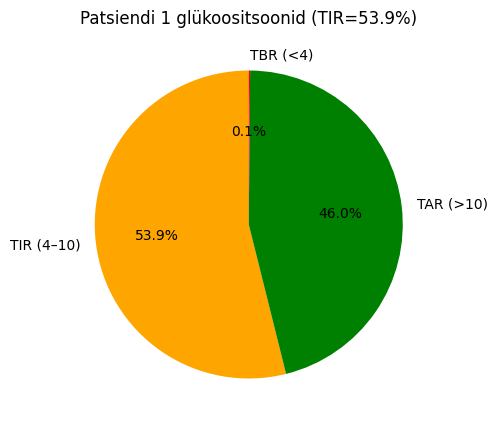

In [ ]:
import numpy as np
pt = 1
start_date = "2017-12-28"
end_date   = "2018-01-12"

subset = df[df['PtID'] == pt].copy()

subset['DataDtTm'] = pd.to_datetime(subset['DataDtTm'])
subset = subset[(subset['DataDtTm'] >= start_date) & (subset['DataDtTm'] <= end_date)]

subset['CGM_mmol'] = subset['CGM'] / 18

subset['zone'] = np.select(
    [subset['CGM_mmol'] < 4,
     subset['CGM_mmol'].between(4, 10),
     subset['CGM_mmol'] > 10],
    ['TBR (<4)', 'TIR (4–10)', 'TAR (>10)'],
    default='missing'
).astype(object)

counts = subset['zone'].value_counts(normalize=True) * 100

plt.figure(figsize=(5,5))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%',
        colors=['orange','green','red','gray'], startangle=90)
plt.title(f'Patsiendi {pt} glükoositsoonid (TIR={counts.get("TIR (4–10)", 0):.1f}%)')
plt.show()


In [ ]:
df['date'] = df['DataDtTm'].dt.date
daily = df.groupby(['PtID', 'date'])['CGM'].agg(['mean', 'std', 'min', 'max'])


In [ ]:
subset = subset.sort_values('DataDtTm')
subset['diff'] = subset['CGM_mmol'].diff()
subset['dt_minutes'] = subset['DataDtTm'].diff().dt.total_seconds() / 60
subset['slope_mmol_per_min'] = subset['diff'] / subset['dt_minutes']
subset.head(25)

,PtID,Period,DataDtTm,CGM,delta_min,CGM_interp,CGM_mmol,in_range,date,zone,diff,dt_minutes,slope_mmol_per_min
4414,1,2. Post Randomization,2017-12-28 00:04:06,175,5.000000,175,9.722222,True,2017-12-28,TIR (4–10),NaN,NaN,NaN
4415,1,2. Post Randomization,2017-12-28 00:09:06,174,5.000000,174,9.666667,True,2017-12-28,TIR (4–10),-0.055556,5.000000,-0.011111
4416,1,2. Post Randomization,2017-12-28 00:14:06,173,5.000000,173,9.611111,True,2017-12-28,TIR (4–10),-0.055556,5.000000,-0.011111
4417,1,2. Post Randomization,2017-12-28 00:19:07,173,5.016667,173,9.611111,True,2017-12-28,TIR (4–10),0.000000,5.016667,0.000000
4418,1,2. Post Randomization,2017-12-28 00:24:06,173,4.983333,173,9.611111,True,2017-12-28,TIR (4–10),0.000000,4.983333,0.000000
4419,1,2. Post Randomization,2017-12-28 00:29:06,172,5.000000,172,9.555556,True,2017-12-28,TIR (4–10),-0.055556,5.000000,-0.011111
4420,1,2. Post Randomization,2017-12-28 00:34:06,171,5.000000,171,9.500000,True,2017-12-28,TIR (4–10),-0.055556,5.000000,-0.011111
4421,1,2. Post Randomization,2017-12-28 00:39:06,169,5.000000,169,9.388889,True,2017-12-28,TIR (4–10),-0.111111,5.000000,-0.022222
4422,1,2. Post Randomization,2017-12-28 00:44:06,169,5.000000,169,9.388889,True,2017-12-28,TIR (4–10),0.000000,5.000000,0.000000
4423,1,2. Post Randomization,2017-12-28 00:49:06,170,5.000000,170,9.444444,True,2017-12-28,TIR (4–10),0.055556,5.000000,0.011111


In [ ]:
subset['is_rising'] = subset['slope_mmol_per_min'] > 0

# Grupeerime järjestikused tõusud
subset['rise_group'] = (subset['is_rising'] != subset['is_rising'].shift()).cumsum()


#arvutame tõusud
rise_segments = (
    subset[subset['is_rising']]
    .groupby('rise_group')
    .agg(
        start_time=('DataDtTm', 'first'),
        end_time=('DataDtTm', 'last'),
        start_value=('CGM_mmol', 'first'),
        end_value=('CGM_mmol', 'last'),
        amplitude=('CGM_mmol', lambda x: x.max() - x.min()),
        duration_min=('dt_minutes', 'sum'),
        mean_slope=('slope_mmol_per_min', 'mean'),
        max_slope=('slope_mmol_per_min', 'max')
    )
).reset_index(drop=True)


In [ ]:
subset.head(102)

,PtID,Period,DataDtTm,CGM,delta_min,CGM_interp,CGM_mmol,in_range,date,zone,diff,dt_minutes,slope_mmol_per_min,is_rising,rise_group
4414,1,2. Post Randomization,2017-12-28 00:04:06,175,5.000000,175,9.722222,True,2017-12-28,TIR (4–10),NaN,NaN,NaN,False,1
4415,1,2. Post Randomization,2017-12-28 00:09:06,174,5.000000,174,9.666667,True,2017-12-28,TIR (4–10),-0.055556,5.000000,-0.011111,False,1
4416,1,2. Post Randomization,2017-12-28 00:14:06,173,5.000000,173,9.611111,True,2017-12-28,TIR (4–10),-0.055556,5.000000,-0.011111,False,1
4417,1,2. Post Randomization,2017-12-28 00:19:07,173,5.016667,173,9.611111,True,2017-12-28,TIR (4–10),0.000000,5.016667,0.000000,False,1
4418,1,2. Post Randomization,2017-12-28 00:24:06,173,4.983333,173,9.611111,True,2017-12-28,TIR (4–10),0.000000,4.983333,0.000000,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4511,1,2. Post Randomization,2017-12-28 08:09:06,128,5.000000,128,7.111111,True,2017-12-28,TIR (4–10),0.055556,5.000000,0.011111,True,22
4512,1,2. Post Randomization,2017-12-28 08:14:06,131,5.000000,131,7.277778,True,2017-12-28,TIR (4–10),0.166667,5.000000,0.033333,True,22
4513,1,2. Post Randomization,2017-12-28 08:19:06,134,5.000000,134,7.444444,True,2017-12-28,TIR (4–10),0.166667,5.000000,0.033333,True,22
4514,1,2. Post Randomization,2017-12-28 08:24:05,141,4.983333,141,7.833333,True,2017-12-28,TIR (4–10),0.388889,4.983333,0.078038,True,22


In [ ]:
subset["is_rising"] = subset["slope_mmol_per_min"] > 0
subset["rise_group"] = (subset["is_rising"] != subset["is_rising"].shift()).cumsum()
long_rises = rise_segments[rise_segments["duration_min"] >= 120]
long_rises["start_hour"] = long_rises["start_time"].dt.hour
print(long_rises["start_hour"].value_counts().sort_index())

start_hour
9     1
10    1
11    1
12    1
23    1
Name: count, dtype: int64


/tmp/ipython-input-938733473.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  long_rises["start_hour"] = long_rises["start_time"].dt.hour


In [ ]:
long_rises["recovery_time_minutes"] = np.nan

for idx, row in long_rises.iterrows():
    peak_time = row["end_time"]
    two_hours_after = peak_time + pd.Timedelta(hours=2)

    # võta selle perioodi kõik mõõtmised
    window = subset[
        (subset["DataDtTm"] > peak_time) &
        (subset["DataDtTm"] <= two_hours_after)
    ]

    # baseline (võid asendada oma baselinem mõistega)
    baseline = subset["CGM_mmol"].median()

    # esimene koht kus langeb baseline+1 lähedale
    hit = window[window["CGM_mmol"] <= baseline + 1]

    if not hit.empty:
        t = (hit.iloc[0]["DataDtTm"] - peak_time).total_seconds()/60
        long_rises.at[idx, "recovery_time_minutes"] = t


/tmp/ipython-input-1436154203.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  long_rises["recovery_time_minutes"] = np.nan


ARVULISELT

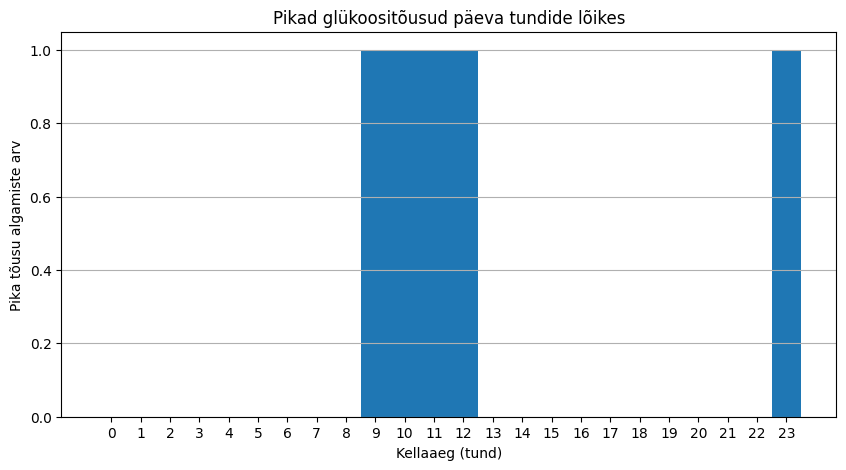

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(long_rises["start_hour"], bins=range(25), align='left')

plt.xticks(range(24))
plt.xlabel("Kellaaeg (tund)")
plt.ylabel("Pika tõusu algamiste arv")
plt.title("Pikad glükoositõusud päeva tundide lõikes")
plt.grid(axis='y')
plt.show()

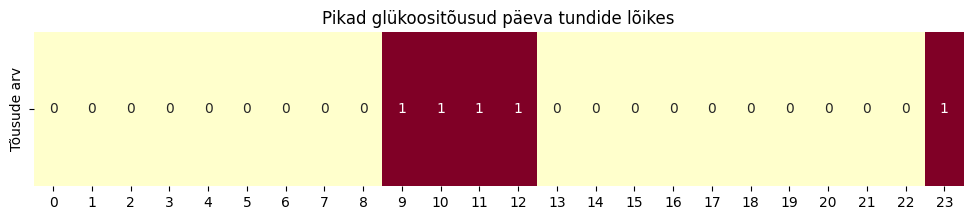

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np

counts = long_rises["start_hour"].value_counts().sort_index()
data = np.zeros((1, 24))
for hour, count in counts.items():
    data[0, hour] = count

plt.figure(figsize=(12,2))
sns.heatmap(data, cmap="YlOrRd", annot=True, cbar=False,
            xticklabels=range(24), yticklabels=["Tõusude arv"])
plt.title("Pikad glükoositõusud päeva tundide lõikes")
plt.show()


In [ ]:
counts = long_rises["start_hour"].value_counts()

mean_count = counts.mean()           # tõusude keskmine arv tunnis
problem_hours = counts[counts > mean_count].index.tolist()

print("Tõusude arv tunniti:")
print(counts.sort_index())

print(f"\nKeskmine tõusude arv tunniti: {mean_count:.2f}")
print("Probleemsed tunnid (rohkem tõuse kui keskmiselt):", problem_hours)


Tõusude arv tunniti:
start_hour
9     1
10    1
11    1
12    1
23    1
Name: count, dtype: int64

Keskmine tõusude arv tunniti: 1.00
Probleemsed tunnid (rohkem tõuse kui keskmiselt): []


In [ ]:
for hour in problem_hours:

    # filtreeri ainult selle tunni tõusud
    subset_rises = long_rises[ long_rises["start_hour"] == hour ].copy()

    if subset_rises.empty:
        continue

    # arvutused
    avg_peak = subset_rises["end_value"].mean()
    max_peak = subset_rises["end_value"].max()

    avg_slope = subset_rises["mean_slope"].mean()
    max_slope = subset_rises["max_slope"].max()

    avg_recovery = subset_rises["recovery_time_minutes"].mean()
    max_recovery = subset_rises["recovery_time_minutes"].max()

    print(f"\n======================")
    print(f"Tund: {hour}")
    print(f"Tõusude arv: {len(subset_rises)}")
    print(f"======================")
    print(f"Keskmine tipp CGM_mmol: {avg_peak:.2f}")
    print(f"Maksimaalne tipp CGM_mmol: {max_peak:.2f}")
    print(f"Keskmine slope (mmol/L/min): {avg_slope:.4f}")
    print(f"Maksimaalne slope (mmol/L/min): {max_slope:.4f}")
    print(f"Keskmine taastumisaeg (min): {avg_recovery:.1f}")
    print(f"Pikim taastumisaeg (min): {max_recovery:.1f}")

#Võrdluseks:
#normaalne tõus pärast väga väikest toitu: ~1 mmol/L tunnis
#märkimisväärne tõus: 2–3 mmol/L tunnis
#tugev söögijärgne tõus: 4+ mmol/L tunnis
#GLP-1 või insuliiniprobleemidega: 5–10+ mmol/L tunnis

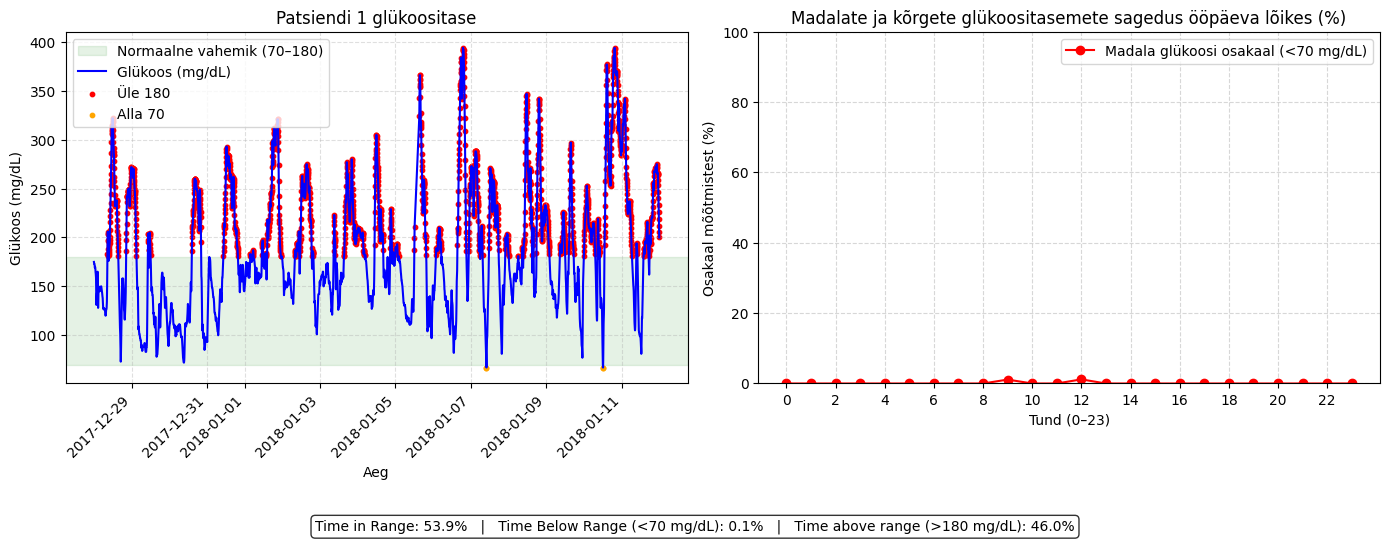

In [ ]:
# teisendame aja datetime'iks
df['DataDtTm'] = pd.to_datetime(df['DataDtTm'], format='%d%b%y:%H:%M:%S')

for pt in range(1,2):
    # vali patsiendi ja kuupäeva vahemiku andmed
    subset = df[
        (df['PtID'] == pt) &
        (df['DataDtTm'].between(start_date, end_date))
    ].copy()

    if subset.empty:
        print(f"Patsiendil {pt} pole andmeid vahemikus {start_date}–{end_date}.")
        continue

    # arvutused
    subset['CGM_mmol'] = subset['CGM'] / 18
    subset['hour'] = subset['DataDtTm'].dt.hour
    subset['is_low'] = subset['CGM'] < 70

    # mitu korda tunnis on väärtus madal
    hourly_low = subset.groupby('hour')['is_low'].mean() * 100

    # --- joonis kahe alamgraafikuga ---
    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    # Vasak: glükoositrend ajas
    ax1 = axes[0]
    ax1.axhspan(70, 180, color='green', alpha=0.1, label='Normaalne vahemik (70–180)')
    ax1.plot(subset['DataDtTm'], subset['CGM'], color='blue', label='Glükoos (mg/dL)')
    ax1.scatter(subset['DataDtTm'][subset['CGM'] > 180], subset['CGM'][subset['CGM'] > 180],
                color='red', s=10, label='Üle 180')
    ax1.scatter(subset['DataDtTm'][subset['CGM'] < 70], subset['CGM'][subset['CGM'] < 70],
                color='orange', s=10, label='Alla 70')
    ax1.set_title(f'Patsiendi {pt} glükoositase')
    ax1.set_xlabel('Aeg')
    ax1.set_ylabel('Glükoos (mg/dL)')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.4)
    plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')


    TIR = (subset['CGM'].between(70,180)).mean() * 100
    TBR = (subset['CGM'] < 70).mean() * 100
    TAR = (subset['CGM'] > 180).mean() * 100
    # Lisa tekst kogu joonise alla (fig tasemel)
    fig.text(0.5, -0.05,
            f"Time in Range: {TIR:.1f}%   |   Time Below Range (<70 mg/dL): {TBR:.1f}%   |   Time above range (>180 mg/dL): {TAR:.1f}%",
            ha='center', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


    ax2 = axes[1]

    # arvutame ka kõrgete väärtuste (TAR) protsendi tunnis
    hourly_high = subset.groupby('hour')['CGM'].apply(lambda x: (x > 180).mean() * 100)

    # joonista mõlemad
    ax2.plot(hourly_low.index, hourly_low.values, marker='o', color='red', label='Madala glükoosi osakaal (<70 mg/dL)')

    ax2.set_ylim(0, 100)

    # lisa abijoon
    ax2.axhline(0, color='gray', linewidth=0.5)

    # sätted
    ax2.set_title('Madalate ja kõrgete glükoositasemete sagedus ööpäeva lõikes (%)')
    ax2.set_xlabel('Tund (0–23)')
    ax2.set_ylabel('Osakaal mõõtmistest (%)')
    ax2.set_xticks(range(0,24,2))
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend()



    plt.tight_layout()
    plt.show()
    print()

Patsient 3

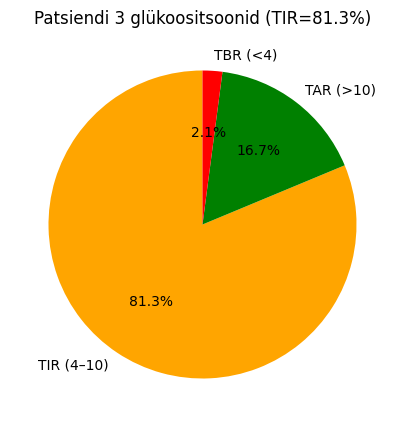

In [ ]:
import numpy as np
pt = 3
start_date = "2017-12-28"
end_date   = "2018-01-12"

subset = df[df['PtID'] == pt].copy()

subset['DataDtTm'] = pd.to_datetime(subset['DataDtTm'])
subset = subset[(subset['DataDtTm'] >= start_date) & (subset['DataDtTm'] <= end_date)]

subset['CGM_mmol'] = subset['CGM'] / 18

subset['zone'] = np.select(
    [subset['CGM_mmol'] < 4,
     subset['CGM_mmol'].between(4, 10),
     subset['CGM_mmol'] > 10],
    ['TBR (<4)', 'TIR (4–10)', 'TAR (>10)'],
    default='missing'
).astype(object)

counts = subset['zone'].value_counts(normalize=True) * 100

plt.figure(figsize=(5,5))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%',
        colors=['orange','green','red','gray'], startangle=90)
plt.title(f'Patsiendi {pt} glükoositsoonid (TIR={counts.get("TIR (4–10)", 0):.1f}%)')
plt.show()


In [ ]:
df['date'] = df['DataDtTm'].dt.date
daily = df.groupby(['PtID', 'date'])['CGM'].agg(['mean', 'std', 'min', 'max'])


In [ ]:
subset = subset.sort_values('DataDtTm')
subset['diff'] = subset['CGM_mmol'].diff()
subset['dt_minutes'] = subset['DataDtTm'].diff().dt.total_seconds() / 60
subset['slope_mmol_per_min'] = subset['diff'] / subset['dt_minutes']
subset.head(25)

,PtID,Period,DataDtTm,CGM,delta_min,CGM_interp,CGM_mmol,in_range,date,zone,diff,dt_minutes,slope_mmol_per_min
4999708,3,1. Baseline,2017-12-28 00:01:21,208,NaN,208,11.555556,False,2017-12-28,TAR (>10),NaN,NaN,NaN
4999709,3,1. Baseline,2017-12-28 00:06:21,201,5.0,201,11.166667,False,2017-12-28,TAR (>10),-0.388889,5.0,-0.077778
4999710,3,1. Baseline,2017-12-28 00:11:21,195,5.0,195,10.833333,False,2017-12-28,TAR (>10),-0.333333,5.0,-0.066667
4999711,3,1. Baseline,2017-12-28 00:16:21,189,5.0,189,10.500000,False,2017-12-28,TAR (>10),-0.333333,5.0,-0.066667
4999712,3,1. Baseline,2017-12-28 00:21:21,182,5.0,182,10.111111,False,2017-12-28,TAR (>10),-0.388889,5.0,-0.077778
4999713,3,1. Baseline,2017-12-28 00:26:21,174,5.0,174,9.666667,True,2017-12-28,TIR (4–10),-0.444444,5.0,-0.088889
4999714,3,1. Baseline,2017-12-28 00:31:21,169,5.0,169,9.388889,True,2017-12-28,TIR (4–10),-0.277778,5.0,-0.055556
4999715,3,1. Baseline,2017-12-28 00:36:21,167,5.0,167,9.277778,True,2017-12-28,TIR (4–10),-0.111111,5.0,-0.022222
4999716,3,1. Baseline,2017-12-28 00:41:21,169,5.0,169,9.388889,True,2017-12-28,TIR (4–10),0.111111,5.0,0.022222
4999717,3,1. Baseline,2017-12-28 00:46:21,172,5.0,172,9.555556,True,2017-12-28,TIR (4–10),0.166667,5.0,0.033333


In [ ]:
subset['is_rising'] = subset['slope_mmol_per_min'] > 0

# Grupeerime järjestikused tõusud
subset['rise_group'] = (subset['is_rising'] != subset['is_rising'].shift()).cumsum()


#arvutame tõusud
rise_segments = (
    subset[subset['is_rising']]
    .groupby('rise_group')
    .agg(
        start_time=('DataDtTm', 'first'),
        end_time=('DataDtTm', 'last'),
        start_value=('CGM_mmol', 'first'),
        end_value=('CGM_mmol', 'last'),
        amplitude=('CGM_mmol', lambda x: x.max() - x.min()),
        duration_min=('dt_minutes', 'sum'),
        mean_slope=('slope_mmol_per_min', 'mean'),
        max_slope=('slope_mmol_per_min', 'max')
    )
).reset_index(drop=True)


In [ ]:
subset.head(102)

,PtID,Period,DataDtTm,CGM,delta_min,CGM_interp,CGM_mmol,in_range,date,zone,diff,dt_minutes,slope_mmol_per_min,is_rising,rise_group
4999708,3,1. Baseline,2017-12-28 00:01:21,208,NaN,208,11.555556,False,2017-12-28,TAR (>10),NaN,NaN,NaN,False,1
4999709,3,1. Baseline,2017-12-28 00:06:21,201,5.000000,201,11.166667,False,2017-12-28,TAR (>10),-0.388889,5.000000,-0.077778,False,1
4999710,3,1. Baseline,2017-12-28 00:11:21,195,5.000000,195,10.833333,False,2017-12-28,TAR (>10),-0.333333,5.000000,-0.066667,False,1
4999711,3,1. Baseline,2017-12-28 00:16:21,189,5.000000,189,10.500000,False,2017-12-28,TAR (>10),-0.333333,5.000000,-0.066667,False,1
4999712,3,1. Baseline,2017-12-28 00:21:21,182,5.000000,182,10.111111,False,2017-12-28,TAR (>10),-0.388889,5.000000,-0.077778,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999805,3,1. Baseline,2017-12-28 08:06:21,91,5.000000,91,5.055556,True,2017-12-28,TIR (4–10),0.055556,5.000000,0.011111,True,20
4999806,3,1. Baseline,2017-12-28 08:11:20,92,4.983333,92,5.111111,True,2017-12-28,TIR (4–10),0.055556,4.983333,0.011148,True,20
4999807,3,1. Baseline,2017-12-28 08:16:20,93,5.000000,93,5.166667,True,2017-12-28,TIR (4–10),0.055556,5.000000,0.011111,True,20
4999808,3,1. Baseline,2017-12-28 08:21:20,95,5.000000,95,5.277778,True,2017-12-28,TIR (4–10),0.111111,5.000000,0.022222,True,20


In [ ]:
subset["is_rising"] = subset["slope_mmol_per_min"] > 0
subset["rise_group"] = (subset["is_rising"] != subset["is_rising"].shift()).cumsum()
long_rises = rise_segments[rise_segments["duration_min"] >= 120]
long_rises["start_hour"] = long_rises["start_time"].dt.hour
print(long_rises["start_hour"].value_counts().sort_index())

Series([], Name: count, dtype: int64)


In [ ]:
long_rises["recovery_time_minutes"] = np.nan

for idx, row in long_rises.iterrows():
    peak_time = row["end_time"]
    two_hours_after = peak_time + pd.Timedelta(hours=2)

    # võta selle perioodi kõik mõõtmised
    window = subset[
        (subset["DataDtTm"] > peak_time) &
        (subset["DataDtTm"] <= two_hours_after)
    ]

    # baseline (võid asendada oma baselinem mõistega)
    baseline = subset["CGM_mmol"].median()

    # esimene koht kus langeb baseline+1 lähedale
    hit = window[window["CGM_mmol"] <= baseline + 1]

    if not hit.empty:
        t = (hit.iloc[0]["DataDtTm"] - peak_time).total_seconds()/60
        long_rises.at[idx, "recovery_time_minutes"] = t


PROTSENTIDES

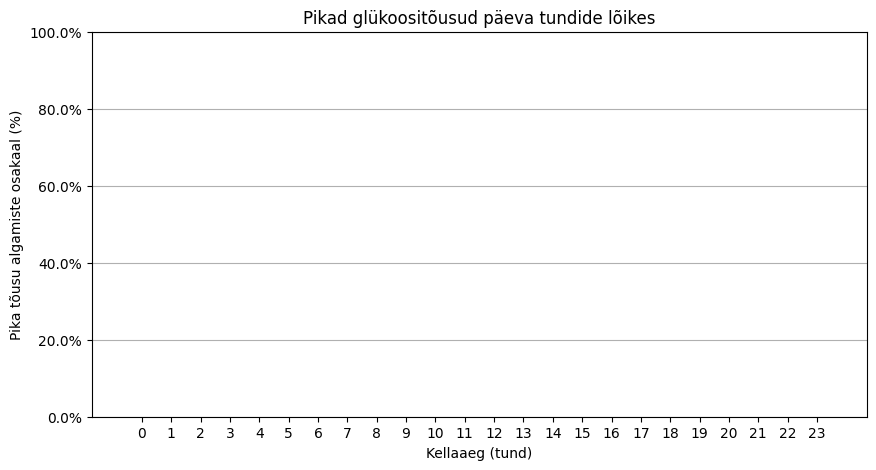

In [ ]:
# arvutame igale vaatlusele 1/N kaalu → histogramm = %
weights = np.ones_like(long_rises["start_hour"]) / len(long_rises)

plt.figure(figsize=(10,5))
plt.hist(long_rises["start_hour"], bins=range(25), align='left',
         weights=weights)   # <-- muudatus
plt.xticks(range(24))
plt.xlabel("Kellaaeg (tund)")
plt.ylabel("Pika tõusu algamiste osakaal (%)")
plt.title("Pikad glükoositõusud päeva tundide lõikes")
plt.ylim(0, 1)
# konverteerime 0–1 → 0–100 %
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.1f}%"))

plt.grid(axis='y')
plt.show()


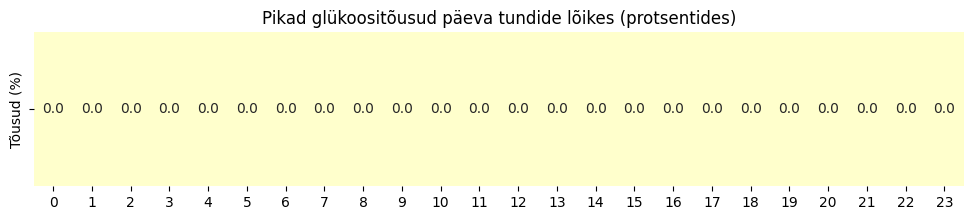

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np

counts = long_rises["start_hour"].value_counts().sort_index()

# arvutame protsendid
percent = (counts / counts.sum()) * 100

# heatmapi jaoks teeme 1 x 24 vektori
data = np.zeros((1, 24))
for hour, p in percent.items():
    data[0, hour] = p

plt.figure(figsize=(12,2))
sns.heatmap(
    data,
    cmap="YlOrRd",
    annot=True,
    fmt=".1f",            # üks komakoht
    cbar=False,
    xticklabels=range(24),
    yticklabels=["Tõusud (%)"]
)

plt.title("Pikad glükoositõusud päeva tundide lõikes (protsentides)")
plt.show()


In [ ]:
counts = long_rises["start_hour"].value_counts()

mean_count = counts.mean()           # tõusude keskmine arv tunnis
problem_hours = counts[counts > mean_count].index.tolist()

print("Tõusude arv tunniti:")
print(counts.sort_index())

print(f"\nKeskmine tõusude arv tunniti: {mean_count:.2f}")
print("Probleemsed tunnid (rohkem tõuse kui keskmiselt):", problem_hours)


Tõusude arv tunniti:
Series([], Name: count, dtype: int64)

Keskmine tõusude arv tunniti: nan
Probleemsed tunnid (rohkem tõuse kui keskmiselt): []


In [ ]:
for hour in problem_hours:

    # filtreeri ainult selle tunni tõusud
    subset_rises = long_rises[ long_rises["start_hour"] == hour ].copy()

    if subset_rises.empty:
        continue

    # arvutused
    avg_peak = subset_rises["end_value"].mean()
    max_peak = subset_rises["end_value"].max()

    avg_slope = subset_rises["mean_slope"].mean()
    max_slope = subset_rises["max_slope"].max()

    avg_recovery = subset_rises["recovery_time_minutes"].mean()
    max_recovery = subset_rises["recovery_time_minutes"].max()

    print(f"\n======================")
    print(f"Tund: {hour}")
    print(f"Tõusude arv: {len(subset_rises)}")
    print(f"======================")
    print(f"Keskmine tipp CGM_mmol: {avg_peak:.2f}")
    print(f"Maksimaalne tipp CGM_mmol: {max_peak:.2f}")
    print(f"Keskmine slope (mmol/L/min): {avg_slope:.4f}")
    print(f"Maksimaalne slope (mmol/L/min): {max_slope:.4f}")
    print(f"Keskmine taastumisaeg (min): {avg_recovery:.1f}")
    print(f"Pikim taastumisaeg (min): {max_recovery:.1f}")

#Võrdluseks:
#normaalne tõus pärast väga väikest toitu: ~1 mmol/L tunnis
#märkimisväärne tõus: 2–3 mmol/L tunnis
#tugev söögijärgne tõus: 4+ mmol/L tunnis
#GLP-1 või insuliiniprobleemidega: 5–10+ mmol/L tunnis

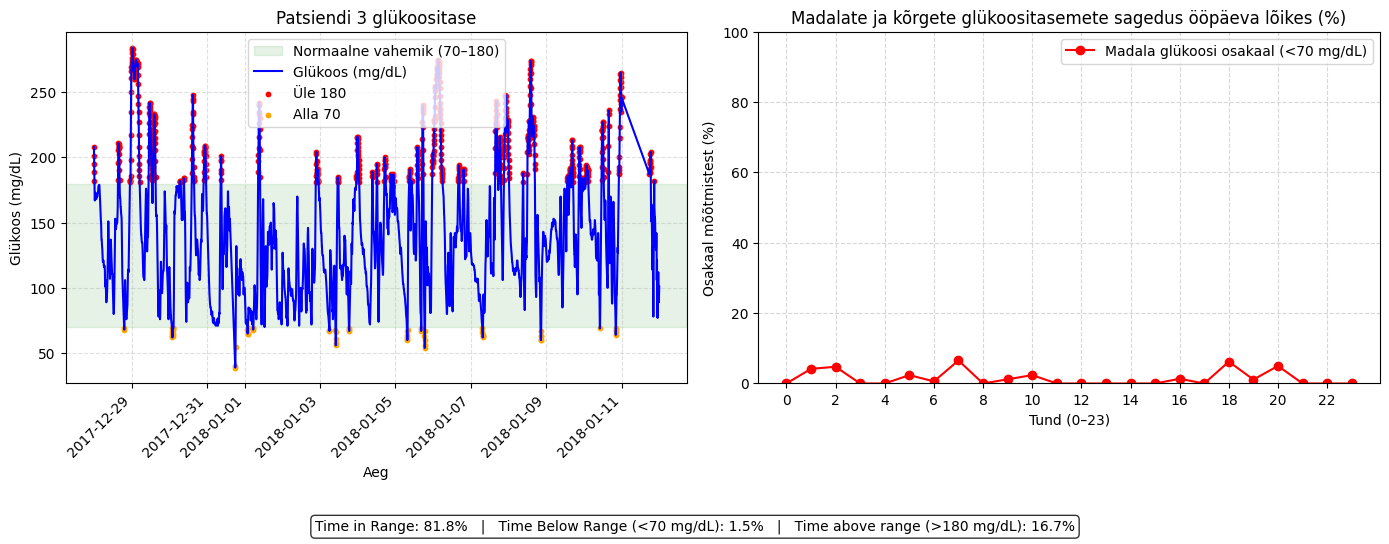

In [ ]:
# teisendame aja datetime'iks
df['DataDtTm'] = pd.to_datetime(df['DataDtTm'], format='%d%b%y:%H:%M:%S')

for pt in range(3,4):
    # vali patsiendi ja kuupäeva vahemiku andmed
    subset = df[
        (df['PtID'] == pt) &
        (df['DataDtTm'].between(start_date, end_date))
    ].copy()

    if subset.empty:
        print(f"Patsiendil {pt} pole andmeid vahemikus {start_date}–{end_date}.")
        continue

    # arvutused
    subset['CGM_mmol'] = subset['CGM'] / 18
    subset['hour'] = subset['DataDtTm'].dt.hour
    subset['is_low'] = subset['CGM'] < 70

    # mitu korda tunnis on väärtus madal
    hourly_low = subset.groupby('hour')['is_low'].mean() * 100

    # --- joonis kahe alamgraafikuga ---
    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    # Vasak: glükoositrend ajas
    ax1 = axes[0]
    ax1.axhspan(70, 180, color='green', alpha=0.1, label='Normaalne vahemik (70–180)')
    ax1.plot(subset['DataDtTm'], subset['CGM'], color='blue', label='Glükoos (mg/dL)')
    ax1.scatter(subset['DataDtTm'][subset['CGM'] > 180], subset['CGM'][subset['CGM'] > 180],
                color='red', s=10, label='Üle 180')
    ax1.scatter(subset['DataDtTm'][subset['CGM'] < 70], subset['CGM'][subset['CGM'] < 70],
                color='orange', s=10, label='Alla 70')
    ax1.set_title(f'Patsiendi {pt} glükoositase')
    ax1.set_xlabel('Aeg')
    ax1.set_ylabel('Glükoos (mg/dL)')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.4)
    plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')


    TIR = (subset['CGM'].between(70,180)).mean() * 100
    TBR = (subset['CGM'] < 70).mean() * 100
    TAR = (subset['CGM'] > 180).mean() * 100
    # Lisa tekst kogu joonise alla (fig tasemel)
    fig.text(0.5, -0.05,
            f"Time in Range: {TIR:.1f}%   |   Time Below Range (<70 mg/dL): {TBR:.1f}%   |   Time above range (>180 mg/dL): {TAR:.1f}%",
            ha='center', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


    ax2 = axes[1]

    # arvutame ka kõrgete väärtuste (TAR) protsendi tunnis
    hourly_high = subset.groupby('hour')['CGM'].apply(lambda x: (x > 180).mean() * 100)

    # joonista mõlemad
    ax2.plot(hourly_low.index, hourly_low.values, marker='o', color='red', label='Madala glükoosi osakaal (<70 mg/dL)')

    ax2.set_ylim(0, 100)

    # lisa abijoon
    ax2.axhline(0, color='gray', linewidth=0.5)

    # sätted
    ax2.set_title('Madalate ja kõrgete glükoositasemete sagedus ööpäeva lõikes (%)')
    ax2.set_xlabel('Tund (0–23)')
    ax2.set_ylabel('Osakaal mõõtmistest (%)')
    ax2.set_xticks(range(0,24,2))
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend()



    plt.tight_layout()
    plt.show()
    print()

Patsient 17

In [236]:
rows_pt17 = df[df["PtID"] == 17]
print(rows_pt17.head(10))

         PtID       Period            DataDtTm  CGM  delta_min  CGM_interp  \
4137729    17  1. Baseline 2018-01-03 00:03:35  366        NaN         366   
4137730    17  1. Baseline 2018-01-03 00:08:35  365   5.000000         365   
4137731    17  1. Baseline 2018-01-03 00:13:36  364   5.016667         364   
4137732    17  1. Baseline 2018-01-03 00:18:35  362   4.983333         362   
4137733    17  1. Baseline 2018-01-03 00:23:35  360   5.000000         360   
4137734    17  1. Baseline 2018-01-03 00:28:35  357   5.000000         357   
4137735    17  1. Baseline 2018-01-03 00:33:35  352   5.000000         352   
4137736    17  1. Baseline 2018-01-03 00:38:35  342   5.000000         342   
4137737    17  1. Baseline 2018-01-03 00:43:35  331   5.000000         331   
4137738    17  1. Baseline 2018-01-03 00:48:35  323   5.000000         323   

          CGM_mmol  in_range        date  
4137729  20.333333     False  2018-01-03  
4137730  20.277778     False  2018-01-03  
4137731  20.

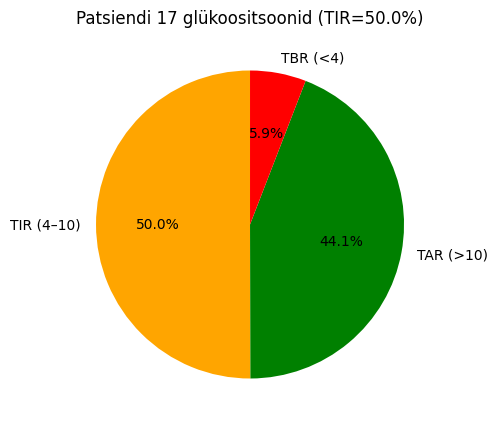

In [237]:
import numpy as np
pt = 17
start_date = "2018-01-03"
end_date   = "2018-01-17"

subset = df[df['PtID'] == pt].copy()

subset['DataDtTm'] = pd.to_datetime(subset['DataDtTm'])
subset = subset[(subset['DataDtTm'] >= start_date) & (subset['DataDtTm'] <= end_date)]

subset['CGM_mmol'] = subset['CGM'] / 18

subset['zone'] = np.select(
    [subset['CGM_mmol'] < 4,
     subset['CGM_mmol'].between(4, 10),
     subset['CGM_mmol'] > 10],
    ['TBR (<4)', 'TIR (4–10)', 'TAR (>10)'],
    default='missing'
).astype(object)

counts = subset['zone'].value_counts(normalize=True) * 100

plt.figure(figsize=(5,5))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%',
        colors=['orange','green','red','gray'], startangle=90)
plt.title(f'Patsiendi {pt} glükoositsoonid (TIR={counts.get("TIR (4–10)", 0):.1f}%)')
plt.show()


In [238]:
df['date'] = df['DataDtTm'].dt.date
daily = df.groupby(['PtID', 'date'])['CGM'].agg(['mean', 'std', 'min', 'max'])


In [239]:
subset = subset.sort_values('DataDtTm')
subset['diff'] = subset['CGM_mmol'].diff()
subset['dt_minutes'] = subset['DataDtTm'].diff().dt.total_seconds() / 60
subset['slope_mmol_per_min'] = subset['diff'] / subset['dt_minutes']
subset.head(25)

,PtID,Period,DataDtTm,CGM,delta_min,CGM_interp,CGM_mmol,in_range,date,zone,diff,dt_minutes,slope_mmol_per_min
4137729,17,1. Baseline,2018-01-03 00:03:35,366,NaN,366,20.333333,False,2018-01-03,TAR (>10),NaN,NaN,NaN
4137730,17,1. Baseline,2018-01-03 00:08:35,365,5.000000,365,20.277778,False,2018-01-03,TAR (>10),-0.055556,5.000000,-0.011111
4137731,17,1. Baseline,2018-01-03 00:13:36,364,5.016667,364,20.222222,False,2018-01-03,TAR (>10),-0.055556,5.016667,-0.011074
4137732,17,1. Baseline,2018-01-03 00:18:35,362,4.983333,362,20.111111,False,2018-01-03,TAR (>10),-0.111111,4.983333,-0.022297
4137733,17,1. Baseline,2018-01-03 00:23:35,360,5.000000,360,20.000000,False,2018-01-03,TAR (>10),-0.111111,5.000000,-0.022222
4137734,17,1. Baseline,2018-01-03 00:28:35,357,5.000000,357,19.833333,False,2018-01-03,TAR (>10),-0.166667,5.000000,-0.033333
4137735,17,1. Baseline,2018-01-03 00:33:35,352,5.000000,352,19.555556,False,2018-01-03,TAR (>10),-0.277778,5.000000,-0.055556
4137736,17,1. Baseline,2018-01-03 00:38:35,342,5.000000,342,19.000000,False,2018-01-03,TAR (>10),-0.555556,5.000000,-0.111111
4137737,17,1. Baseline,2018-01-03 00:43:35,331,5.000000,331,18.388889,False,2018-01-03,TAR (>10),-0.611111,5.000000,-0.122222
4137738,17,1. Baseline,2018-01-03 00:48:35,323,5.000000,323,17.944444,False,2018-01-03,TAR (>10),-0.444444,5.000000,-0.088889


In [240]:
subset['is_rising'] = subset['slope_mmol_per_min'] > 0

# Grupeerime järjestikused tõusud
subset['rise_group'] = (subset['is_rising'] != subset['is_rising'].shift()).cumsum()


#arvutame tõusud
rise_segments = (
    subset[subset['is_rising']]
    .groupby('rise_group')
    .agg(
        start_time=('DataDtTm', 'first'),
        end_time=('DataDtTm', 'last'),
        start_value=('CGM_mmol', 'first'),
        end_value=('CGM_mmol', 'last'),
        amplitude=('CGM_mmol', lambda x: x.max() - x.min()),
        duration_min=('dt_minutes', 'sum'),
        mean_slope=('slope_mmol_per_min', 'mean'),
        max_slope=('slope_mmol_per_min', 'max')
    )
).reset_index(drop=True)


In [241]:
subset.head(102)

,PtID,Period,DataDtTm,CGM,delta_min,CGM_interp,CGM_mmol,in_range,date,zone,diff,dt_minutes,slope_mmol_per_min,is_rising,rise_group
4137729,17,1. Baseline,2018-01-03 00:03:35,366,NaN,366,20.333333,False,2018-01-03,TAR (>10),NaN,NaN,NaN,False,1
4137730,17,1. Baseline,2018-01-03 00:08:35,365,5.000000,365,20.277778,False,2018-01-03,TAR (>10),-0.055556,5.000000,-0.011111,False,1
4137731,17,1. Baseline,2018-01-03 00:13:36,364,5.016667,364,20.222222,False,2018-01-03,TAR (>10),-0.055556,5.016667,-0.011074,False,1
4137732,17,1. Baseline,2018-01-03 00:18:35,362,4.983333,362,20.111111,False,2018-01-03,TAR (>10),-0.111111,4.983333,-0.022297,False,1
4137733,17,1. Baseline,2018-01-03 00:23:35,360,5.000000,360,20.000000,False,2018-01-03,TAR (>10),-0.111111,5.000000,-0.022222,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4137826,17,1. Baseline,2018-01-03 08:08:34,144,5.016667,144,8.000000,True,2018-01-03,TIR (4–10),-0.111111,5.016667,-0.022148,False,11
4137827,17,1. Baseline,2018-01-03 08:13:33,143,4.983333,143,7.944444,True,2018-01-03,TIR (4–10),-0.055556,4.983333,-0.011148,False,11
4137828,17,1. Baseline,2018-01-03 08:18:34,141,5.016667,141,7.833333,True,2018-01-03,TIR (4–10),-0.111111,5.016667,-0.022148,False,11
4137829,17,1. Baseline,2018-01-03 08:23:33,138,4.983333,138,7.666667,True,2018-01-03,TIR (4–10),-0.166667,4.983333,-0.033445,False,11


In [242]:
subset["is_rising"] = subset["slope_mmol_per_min"] > 0
subset["rise_group"] = (subset["is_rising"] != subset["is_rising"].shift()).cumsum()
long_rises = rise_segments[rise_segments["duration_min"] >= 120]
long_rises["start_hour"] = long_rises["start_time"].dt.hour
print(long_rises["start_hour"].value_counts().sort_index())

start_hour
12    2
13    1
14    1
16    1
17    3
18    1
19    1
Name: count, dtype: int64


/tmp/ipython-input-938733473.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  long_rises["start_hour"] = long_rises["start_time"].dt.hour


In [243]:
long_rises["recovery_time_minutes"] = np.nan

for idx, row in long_rises.iterrows():
    peak_time = row["end_time"]
    two_hours_after = peak_time + pd.Timedelta(hours=2)

    # võta selle perioodi kõik mõõtmised
    window = subset[
        (subset["DataDtTm"] > peak_time) &
        (subset["DataDtTm"] <= two_hours_after)
    ]

    # baseline (võid asendada oma baselinem mõistega)
    baseline = subset["CGM_mmol"].median()

    # esimene koht kus langeb baseline+1 lähedale
    hit = window[window["CGM_mmol"] <= baseline + 1]

    if not hit.empty:
        t = (hit.iloc[0]["DataDtTm"] - peak_time).total_seconds()/60
        long_rises.at[idx, "recovery_time_minutes"] = t


/tmp/ipython-input-1436154203.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  long_rises["recovery_time_minutes"] = np.nan


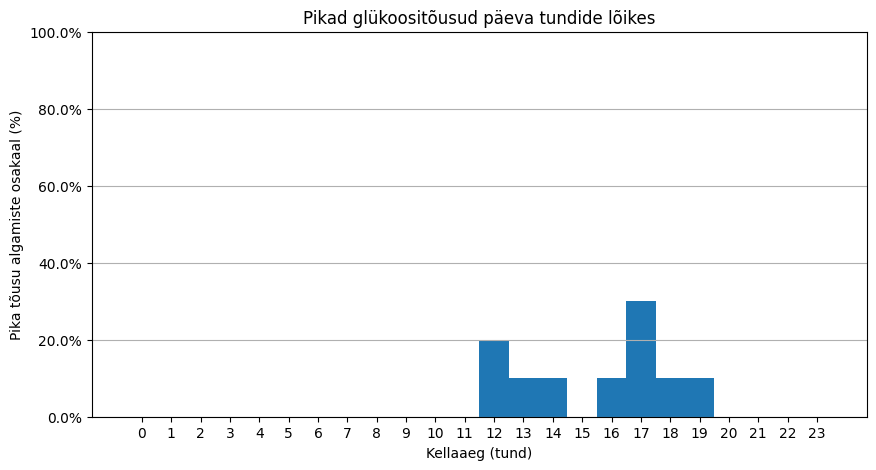

In [244]:
# arvutame igale vaatlusele 1/N kaalu → histogramm = %
weights = np.ones_like(long_rises["start_hour"]) / len(long_rises)

plt.figure(figsize=(10,5))
plt.hist(long_rises["start_hour"], bins=range(25), align='left',
         weights=weights)   # <-- muudatus
plt.xticks(range(24))
plt.xlabel("Kellaaeg (tund)")
plt.ylabel("Pika tõusu algamiste osakaal (%)")
plt.title("Pikad glükoositõusud päeva tundide lõikes")
plt.ylim(0, 1)
# konverteerime 0–1 → 0–100 %
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.1f}%"))

plt.grid(axis='y')
plt.show()


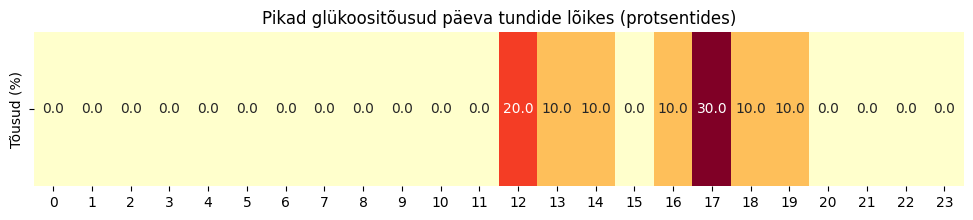

In [245]:
import seaborn as sns
import pandas as pd
import numpy as np

counts = long_rises["start_hour"].value_counts().sort_index()

# arvutame protsendid
percent = (counts / counts.sum()) * 100

# heatmapi jaoks teeme 1 x 24 vektori
data = np.zeros((1, 24))
for hour, p in percent.items():
    data[0, hour] = p

plt.figure(figsize=(12,2))
sns.heatmap(
    data,
    cmap="YlOrRd",
    annot=True,
    fmt=".1f",            # üks komakoht
    cbar=False,
    xticklabels=range(24),
    yticklabels=["Tõusud (%)"]
)

plt.title("Pikad glükoositõusud päeva tundide lõikes (protsentides)")
plt.show()


In [246]:
counts = long_rises["start_hour"].value_counts()

mean_count = counts.mean()           # tõusude keskmine arv tunnis
problem_hours = counts[counts > mean_count].index.tolist()

print("Tõusude arv tunniti:")
print(counts.sort_index())

print(f"\nKeskmine tõusude arv tunniti: {mean_count:.2f}")
print("Probleemsed tunnid (rohkem tõuse kui keskmiselt):", problem_hours)


Tõusude arv tunniti:
start_hour
12    2
13    1
14    1
16    1
17    3
18    1
19    1
Name: count, dtype: int64

Keskmine tõusude arv tunniti: 1.43
Probleemsed tunnid (rohkem tõuse kui keskmiselt): [17, 12]


In [247]:
for hour in problem_hours:

    # filtreeri ainult selle tunni tõusud
    subset_rises = long_rises[ long_rises["start_hour"] == hour ].copy()

    if subset_rises.empty:
        continue

    # arvutused
    avg_peak = subset_rises["end_value"].mean()
    max_peak = subset_rises["end_value"].max()

    avg_slope = subset_rises["mean_slope"].mean()
    max_slope = subset_rises["max_slope"].max()

    avg_recovery = subset_rises["recovery_time_minutes"].mean()
    max_recovery = subset_rises["recovery_time_minutes"].max()

    print(f"\n======================")
    print(f"Tund: {hour}")
    print(f"Tõusude arv: {len(subset_rises)}")
    print(f"======================")
    print(f"Keskmine tipp CGM_mmol: {avg_peak:.2f}")
    print(f"Maksimaalne tipp CGM_mmol: {max_peak:.2f}")
    print(f"Keskmine slope (mmol/L/min): {avg_slope:.4f}")
    print(f"Maksimaalne slope (mmol/L/min): {max_slope:.4f}")
    print(f"Keskmine taastumisaeg (min): {avg_recovery:.1f}")
    print(f"Pikim taastumisaeg (min): {max_recovery:.1f}")

#Võrdluseks:
#normaalne tõus pärast väga väikest toitu: ~1 mmol/L tunnis
#märkimisväärne tõus: 2–3 mmol/L tunnis
#tugev söögijärgne tõus: 4+ mmol/L tunnis
#GLP-1 või insuliiniprobleemidega: 5–10+ mmol/L tunnis


Tund: 17
Tõusude arv: 3
Keskmine tipp CGM_mmol: 18.22
Maksimaalne tipp CGM_mmol: 20.72
Keskmine slope (mmol/L/min): 0.0685
Maksimaalne slope (mmol/L/min): 0.1889
Keskmine taastumisaeg (min): nan
Pikim taastumisaeg (min): nan

Tund: 12
Tõusude arv: 2
Keskmine tipp CGM_mmol: 13.00
Maksimaalne tipp CGM_mmol: 16.50
Keskmine slope (mmol/L/min): 0.0703
Maksimaalne slope (mmol/L/min): 0.1222
Keskmine taastumisaeg (min): 52.5
Pikim taastumisaeg (min): 100.0


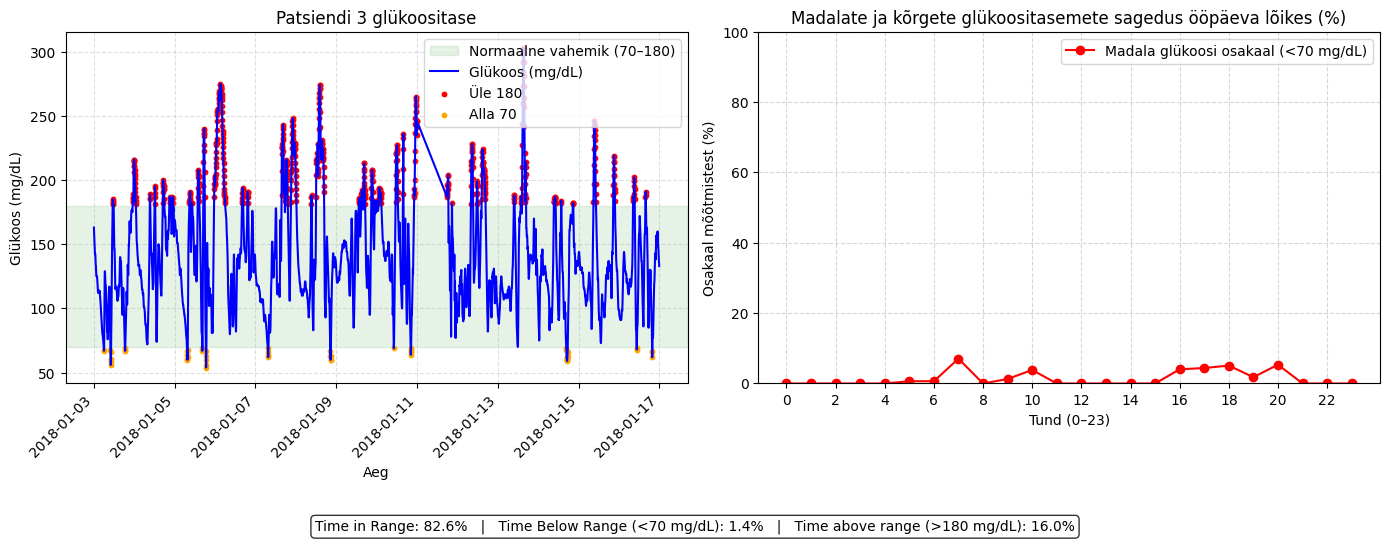

In [248]:
# teisendame aja datetime'iks
df['DataDtTm'] = pd.to_datetime(df['DataDtTm'], format='%d%b%y:%H:%M:%S')

for pt in range(3,4):
    # vali patsiendi ja kuupäeva vahemiku andmed
    subset = df[
        (df['PtID'] == pt) &
        (df['DataDtTm'].between(start_date, end_date))
    ].copy()

    if subset.empty:
        print(f"Patsiendil {pt} pole andmeid vahemikus {start_date}–{end_date}.")
        continue

    # arvutused
    subset['CGM_mmol'] = subset['CGM'] / 18
    subset['hour'] = subset['DataDtTm'].dt.hour
    subset['is_low'] = subset['CGM'] < 70

    # mitu korda tunnis on väärtus madal
    hourly_low = subset.groupby('hour')['is_low'].mean() * 100

    # --- joonis kahe alamgraafikuga ---
    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    # Vasak: glükoositrend ajas
    ax1 = axes[0]
    ax1.axhspan(70, 180, color='green', alpha=0.1, label='Normaalne vahemik (70–180)')
    ax1.plot(subset['DataDtTm'], subset['CGM'], color='blue', label='Glükoos (mg/dL)')
    ax1.scatter(subset['DataDtTm'][subset['CGM'] > 180], subset['CGM'][subset['CGM'] > 180],
                color='red', s=10, label='Üle 180')
    ax1.scatter(subset['DataDtTm'][subset['CGM'] < 70], subset['CGM'][subset['CGM'] < 70],
                color='orange', s=10, label='Alla 70')
    ax1.set_title(f'Patsiendi {pt} glükoositase')
    ax1.set_xlabel('Aeg')
    ax1.set_ylabel('Glükoos (mg/dL)')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.4)
    plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')


    TIR = (subset['CGM'].between(70,180)).mean() * 100
    TBR = (subset['CGM'] < 70).mean() * 100
    TAR = (subset['CGM'] > 180).mean() * 100
    # Lisa tekst kogu joonise alla (fig tasemel)
    fig.text(0.5, -0.05,
            f"Time in Range: {TIR:.1f}%   |   Time Below Range (<70 mg/dL): {TBR:.1f}%   |   Time above range (>180 mg/dL): {TAR:.1f}%",
            ha='center', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


    ax2 = axes[1]

    # arvutame ka kõrgete väärtuste (TAR) protsendi tunnis
    hourly_high = subset.groupby('hour')['CGM'].apply(lambda x: (x > 180).mean() * 100)

    # joonista mõlemad
    ax2.plot(hourly_low.index, hourly_low.values, marker='o', color='red', label='Madala glükoosi osakaal (<70 mg/dL)')

    ax2.set_ylim(0, 100)

    # lisa abijoon
    ax2.axhline(0, color='gray', linewidth=0.5)

    # sätted
    ax2.set_title('Madalate ja kõrgete glükoositasemete sagedus ööpäeva lõikes (%)')
    ax2.set_xlabel('Tund (0–23)')
    ax2.set_ylabel('Osakaal mõõtmistest (%)')
    ax2.set_xticks(range(0,24,2))
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend()



    plt.tight_layout()
    plt.show()
    print()